<a href="https://colab.research.google.com/github/JorgeGonSan/JorgeGonSan/blob/main/cyclistic_by_JorgeGongora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFORME DE CASO DE ESTUDIO: CYCLISTIC


---



# 1. Declaración de la tarea empresarial
- El objetivo de este análisis es responder de forma concreta a la pregunta asignada por la directora de marketing, Lily Moreno: ¿Cómo se relacionan y difieren los patrones de uso de las bicicletas compartidas entre los miembros anuales y los usuarios ocasionales de Cyclistic?

- A través de la identificación de estas diferencias de comportamiento (horarios, días de la semana, duración de los viajes, etc.), se busca proporcionar una base sólida de datos que permita al equipo de marketing entender el perfil del usuario ocasional.

- Partes interesadas: Los resultados de este estudio se presentarán directamente a Lily Moreno (directora de marketing) quien tomarán la decisión final sobre la aprobación y el presupuesto de la nueva estrategia digital.
---



# 2.   Descripción  de  todas  las  fuentes  de  datos utilizadas

- Para realizar el estudio se han utilizado el histrico de viajes de Cyclistic, en concreto se han utilizado los ultimos 12 meses.
- Estos datos son proporcionados por Motivate International en el siguiente enlace -> [datos de viajes](https://divvy-tripdata.s3.amazonaws.com/index.html)
- bajo la siguiente licencia de uso -> [licencia](https://divvybikes.com/data-license-agreement)
- Los datos son anónimos y no son manipulabres, solo se permite la descarga de los mismo sin manipulación en el origen.
- Los datos de los ultimos 12 meses estan organizados, en archivos individuales uno por cada mes, el archivo denominado 202501 contiene datos de Enero del 2026 por lo que se renombra para garantizar la integridad de los datos a 202601.
- Los datos estan estructurados en formato de tabla, donde cada fila corresponde a un trayecto único de una bicicleta.
- Se ha observado datos nulos en los nombre de las estaciones y en menor cantidad en las coordenadas del trayecto de la estación.


---






# 3.  Documentación  de  cualquier  limpieza  o  manipulación  de datos.
- Dado el volumen de datos se descarta usar hojas de cálculos
- Se ha creado una carpeta con los archivos originales, y se ha realizado una copia renombrando cada archivo en formato "mes-año" por ejemplo "may2025.csv" corresponde al periodo de Mayo del 2025.
- Se ha utilizado **Python con Pandas** para convertir cada archivo en un dataframe





In [1]:

import pandas as pd

ruta = abr2026 = "/content/drive/MyDrive/HOJAS_CURSO_ANALISIS_DATOS/cyclistic/Cambio_nombres/"

may2025 = pd.read_csv(f"{ruta}may2025.csv")
jun2025 = pd.read_csv(f"{ruta}jun2025.csv")
jul2025 = pd.read_csv(f"{ruta}jul2025.csv")
ago2025 = pd.read_csv(f"{ruta}ago2025.csv")
sep2025 = pd.read_csv(f"{ruta}sep2025.csv")
oct2025 = pd.read_csv(f"{ruta}oct2025.csv")
nov2025 = pd.read_csv(f"{ruta}nov2025.csv")
dic2025 = pd.read_csv(f"{ruta}dic2025.csv")
ene2026 = pd.read_csv(f"{ruta}ene2026.csv")
feb2026 = pd.read_csv(f"{ruta}feb2026.csv")
mar2026 = pd.read_csv(f"{ruta}mar2026.csv")
abr2026 = pd.read_csv(f"{ruta}abr2026.csv")

In [2]:
# Se comprueba para cada mes que las columnas son identicas
may2025.columns == jun2025.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

- Se ha unido todos los meses en un único archivo llamado **viajesMay2025aAbr2026**y se ha comprobado su integridad.

In [3]:
# Se crea archivo único
viajesMay2025aAbr2026 = pd.concat([may2025, jun2025, jul2025, ago2025, sep2025, oct2025, nov2025, dic2025, ene2026, feb2026, mar2026, abr2026])
# Se guarda archivo
viajesMay2025aAbr2026.to_csv(f"{ruta}viajesMay2025aAbr2026.csv")
# Se comprueba integridad de datos
len(viajesMay2025aAbr2026) == len(may2025) + len(jun2025) + len(jul2025) + len(ago2025) + len(sep2025) + len(oct2025) + len(nov2025) + len(dic2025) + len(ene2026) + len(feb2026) + len(mar2026) + len(abr2026)

True

In [8]:
# Se convierte la columnas de texto a fechas reales
viajesMay2025aAbr2026["started_at"] = pd.to_datetime(viajesMay2025aAbr2026["started_at"])
viajesMay2025aAbr2026["ended_at"] = pd.to_datetime(viajesMay2025aAbr2026["ended_at"])

# Se crea una columna calculada con el tiempo total del viaje en segundos
viajesMay2025aAbr2026["tiempo_viaje"] = (viajesMay2025aAbr2026["ended_at"] - viajesMay2025aAbr2026["started_at"]).dt.total_seconds()

#actualizamos, solo con los archivos con valor de recorrido positivos
viajesMay2025aAbr2026 = viajesMay2025aAbr2026[viajesMay2025aAbr2026["tiempo_viaje"] > 0]



In [9]:
#Se comprueba que no existen valores duplicados
duplicados = viajesMay2025aAbr2026.duplicated(subset=["ride_id"]).sum()
print(duplicados)


0


- Se ha decidido mantener los valores nulos ya que en las columnas que estan no son relevantes para el estudio de la relación entre tipos de usuarios.

In [10]:
# Se comprueban valores nulos
viajesMay2025aAbr2026.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,1215741
start_station_id,1215741
end_station_name,1279857
end_station_id,1279857
start_lat,0
start_lng,0


In [11]:
#Se añade columna que indica el dia de la semana que se inicia el viaje 0 = Lunes; 6 = Domingo
viajesMay2025aAbr2026["dia_de_la_semana"] = viajesMay2025aAbr2026["started_at"].dt.dayofweek
#Actualizo archivo
viajesMay2025aAbr2026.to_csv(f"{ruta}viajesMay2025aAbr2026.csv")






---


#4. Resumen  del  análisis

- Tras limpiar el conjunto de datos, se dispone de un total de 5.69 millones de trayectos válidos.
- Se analizan las estadísticas descriptivas generales de la duración de los viajes

In [15]:
# estadisticas descriptivas del campo de la duración de los viajes count cantidad de trayectos y el resto de los valores estan en segundos.
viajesMay2025aAbr2026["tiempo_viaje"].describe()

,tiempo_viaje
count,5697426.00
mean,961.01
std,3334.92
min,0.05
25%,322.34
50%,563.75
75%,991.62
max,94494.01


### 4.1. Comparación de la duración del viaje por tipo de usuario
- Se agrupan los viajes por tipo de usuario para identificar diferencias de uso entre ambos y se muestra la media, mediana, máximo y minimo.

> Los usuarios ocasionales duplican la duración media de los viajes en comparación con los usuarios con abono anual

In [18]:
#Muestra media,mediana,max y minimo de los viajes agrupada por tipo de usuario en segundos
viajesMay2025aAbr2026.groupby("member_casual")["tiempo_viaje"].agg(["mean","median","max","min"])

,mean,median,max,min
member_casual,,,,
casual,1346.90,678.24,94494.01,0.05
member,746.14,514.73,93594.22,0.07


### 4.2. Análisis del volumen de viajes por día de la semana
- Se analiza como varia el promedio de los viajes de los usuarios según el dia de la semana, ordenados de menor a mayor, siendo 0 el Lunes y 6 el Domingo

- Los miembros anuales: Mantienen una cosntante de lunes a Viernes entre 720-740 segundos (unos 12 minutos).
- El fin de semana hay un ligero aumento, rondando los 13,6 minutos de media(819 segundos).

- Los usuarios ocasionales: Sus viajes son siempre largos al rededor de 20 minutos, pero el fin de semana se disparan notablemente, alcanzando los **1557 segundos el Domingo** (casi 26 minutos por viaje).

> Los Miembros anules tiene un tiempo de uso por viaje practicamente fijo durante toda la semana con un ligero aumento los fines de semana por el contrario los usuarios ocasionales aumenta notablemente el tiempo de viaje los fines de semana.

In [19]:
#Media de tiempo de viajes por tipo de usuario según el dia de la semana siendo 0 Lunes y 6 Domingo en segundos
viajesMay2025aAbr2026.groupby(["member_casual","dia_de_la_semana"])["tiempo_viaje"].mean()

member_casual  dia_de_la_semana
casual         0                  1337.37
               1                  1170.28
               2                  1128.12
               3                  1190.72
               4                  1334.32
               5                  1508.25
               6                  1557.71
member         0                   725.92
               1                   720.51
               2                   714.91
               3                   720.49
               4                   742.39
               5                   816.93
               6                   819.37
Name: tiempo_viaje, dtype: float64

### 4.3. Análisis del volumen de viajes por día de la semana
- Agrupamos los datos por tipo de usuario (`member_casual`) y día de la semana (0 = Lunes, 6 = Domingo) y calculamos el total de viajes para cada uno de ellos

- Los miembros anuales: Registran su actividad máxima y constante de Lunes a Viernes, alcanzando su pico máximo el Jueves con 602,097 viajes. En cambio, su uso cae durante el fin de semana.
- Los usuarios ocasionales : Muestran el comportamiento inverso; la cantidad de viaje son bajos durante los días laborables pero se disparan los fines de semana, logrando su pico máximo el Sábado con 416,578 viajes.

> Los miembros anuales usan la bicicleta en su rutina de transporte semanal (trabajo o estudios), mientras que los usuarios ocasionales la usan principalmente como una actividad recreativa y/u ocio para sus días de descanso.

In [20]:
#Cantidad de viajes por miembro en cada dia de la semana, siendo 0 Lunes y 6 Domingo
viajesMay2025aAbr2026.groupby(["member_casual","dia_de_la_semana"]).size()

member_casual  dia_de_la_semana
casual         0                   232913
               1                   229268
               2                   229446
               3                   268851
               4                   320542
               5                   416578
               6                   340190
member         0                   513977
               1                   580962
               2                   578335
               3                   602097
               4                   538796
               5                   453952
               6                   391519
dtype: int64

### 4.4. Preferencia del tipo de bicicleta por segmento de usuario

- Se analiza el tipo de bicicletas segun el tipo de usuario.

* **Bicicletas Eléctricas (`electric_bike`):** Es la opción más popular por una diferencia abismal en ambos grupos, registrando **1,374,835 viajes** por usuarios ocasionales y **2,386,278 viajes** por miembros anuales.
* **Bicicletas Clásicas (`classic_bike`):** Registran un volumen menor pero muy sólido, con **662,953 viajes** de usuarios ocasionales y **1,273,360** de miembros.

> El tipo de bicicleta no actúa como un factor diferencial entre los dos perfiles.  
independientemente de si el trayecto es por ocio o por rutina laboral.

In [21]:
viajesMay2025aAbr2026.groupby(['member_casual', 'rideable_type']).size()

member_casual  rideable_type
casual         classic_bike      662953
               electric_bike    1374835
member         classic_bike     1273360
               electric_bike    2386278
dtype: int64

### 4.5. Limitaciones del análisis y hallazgos operacionales

Analizando los datos, el domingo caen los viajes en los dos grupos, aunque la gente que coge las bicis los domingos las usa durante mucho más tiempo.

> No podemos analizar si es debido a la ausencia del tipo electrico que es el preferido por ambos usuarios ya que no disponemos datos del stock de bicicletas de cada modelo.




---


# 5. Visualizaciones  de  apoyo  y  hallazgos  clave.

- En este punto, se transforman los datos limpios y resumidos en elementos visuales utilizando **Tableau**.



## 5.1. Análisis del Volumen de Viajes por Día de la Semana y Tipo de Usuario

🔗 **[Ver gráfico interactivo en Tableau Public](https://public.tableau.com/app/profile/jorge.g.ngora7105/viz/CyclisticbyJGS/DuracinMediadeviajesporDayTipodeUsuario)**


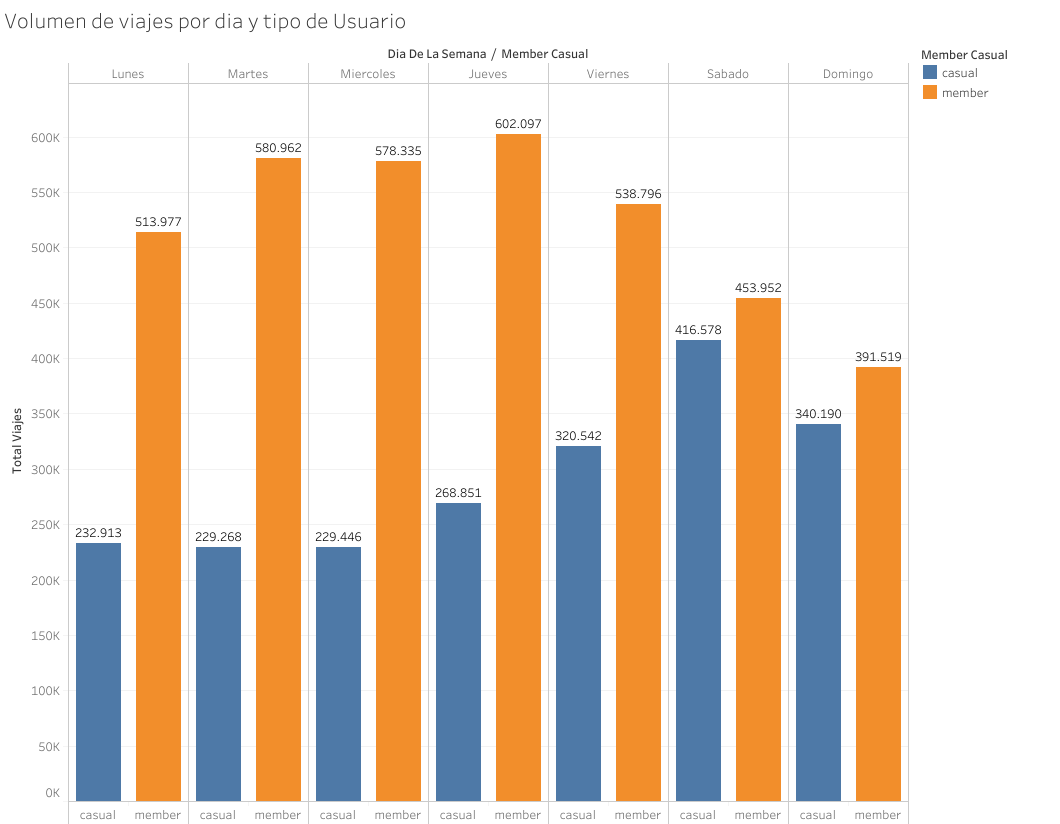


* **Member (Naranja):** Máximo uso de lunes a viernes (pico el jueves con ~602K) y caída drástica el fin de semana.
* **Casual (Azul):** Mínimo uso entre semana y aumento el fin de semana (pico el sábado con ~416K).



## 5.2. Volumen Total de Viajes por Día de la Semana

🔗 [Ver Gráfico 1 Interactivo en Tableau Public](https://public.tableau.com/app/profile/jorge.g.ngora7105/viz/CyclisticbyJGS/DuracinMediadeviajesporDayTipodeUsuario)

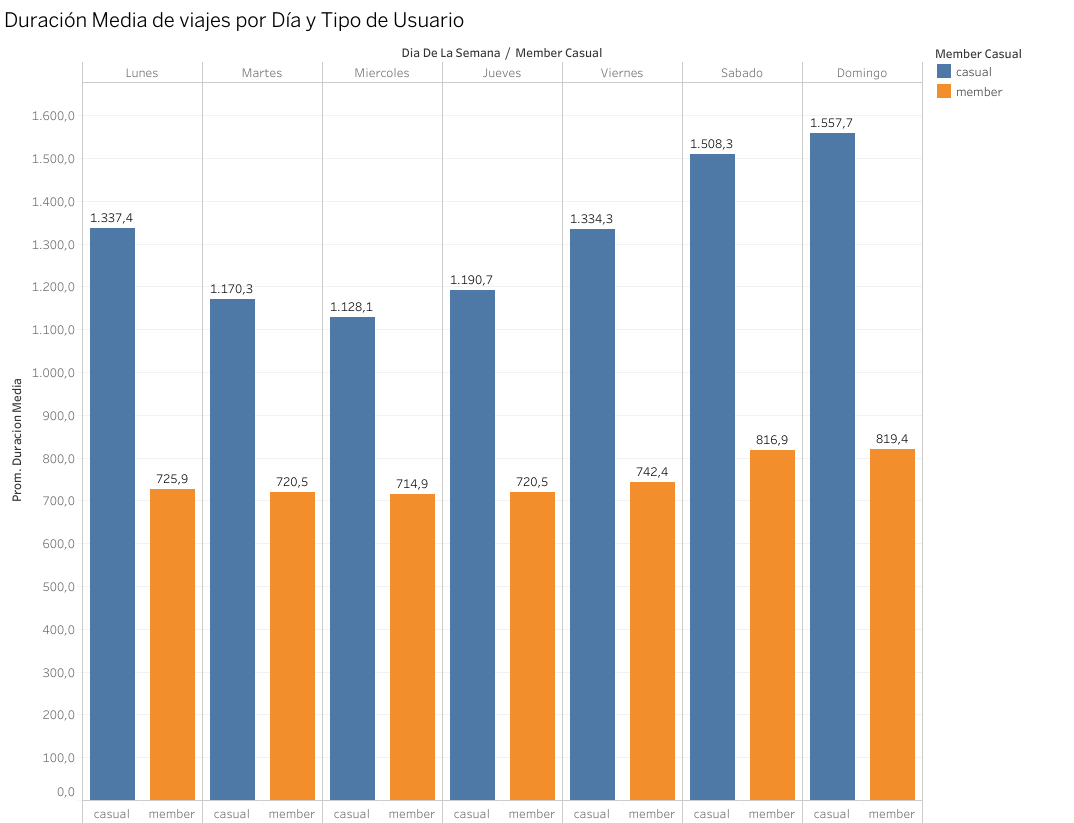




- **Casual (Azul):** Hacen viajes mas largos durante toda la semana, con una duración estable de unos 20 minutos de lunes a viernes, que se dispara el fin de semana hasta un pico de 26 minutos (1.557,7 segundos) el domingo.

- **Member (Naranja):** Tienen un uso lineal. Su tiempo de viaje se queda fijo en unos 12 minutos (720 segundos) de lunes a viernes, con apenas un ligero aumento de un minuto los fines de semana.

## 5.3. Distribución y Preferencia de Uso por Tipo de Bicicleta

🔗 [Ver Gráfico 3 Interactivo en Tableau Public](https://public.tableau.com/app/profile/jorge.g.ngora7105/viz/CyclisticbyJGS/DuracinMediadeviajesporDayTipodeUsuario)

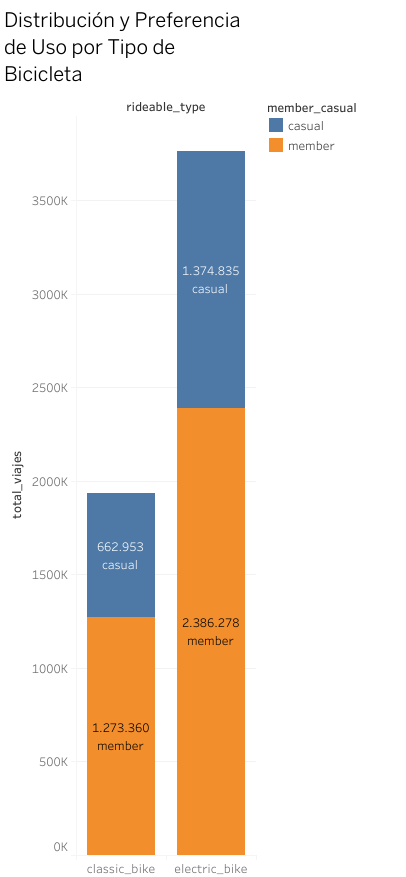


- La bicicleta eléctrica (`electric_bike`) es la reina absoluta del servicio. Tanto los miembros (2.4M de viajes) como los ocasionales (1.4M) la eligen masivamente por encima de la clásica.


# 6. Principales recomendaciones basadas en su análisis

### Campañas enfocadas al ocio y planes de fin de semana
* **El análisis:** Dado que los datos nos indican que los usuarios casuales usan las bicicletas el doble de tiempo que los usuarios anuales, y a su vez vemos que los fines de semana hay un aumento de tiempo de uso, está claro que el usuario casual entiende el uso de la bicicleta como una actividad de ocio.
* **Recomendaciones:**
    * Se podrían enfocar campañas con imágenes familiares y de ocio donde se promocione el uso de la bicicleta. La idea clave es vender la membresía anual como la herramienta perfecta para disfrutar de tu bici los fines de semana sin límites, asociándola a planes libres y tiempo de desconexión.
    * Se podría estudiar la opción de un pase intermedio con abonos de fines de semana, o aplicar un descuento en el abono anual si solo se usa durante el fin de semana, dado que en esos días es donde hay mayores repuntes de uso.
    * El aumento del parque de bicicletas eléctricas podría fomentar un mayor uso, ya que en los datos vemos que casi dobla el uso respecto a las convencionales, aunque para confirmarlo del todo necesitaríamos datos sobre qué proporción de bicicletas de cada tipo dispone actualmente la empresa.

